In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "6"

import torch
print(torch.cuda.device_count())   # should be 1 now
print(torch.cuda.get_device_name(0))  # GPU 8 will appear as cuda:0

import torch

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Number of visible GPUs: {torch.cuda.device_count()}")

for i in range(torch.cuda.device_count()):
    print(f"Device {i}: {torch.cuda.get_device_name(i)}")



1
NVIDIA L40S
CUDA available: True
Number of visible GPUs: 1
Device 0: NVIDIA L40S


In [2]:
import cv2
import numpy as np
import random
import torch
import gc
import os
import pandas as pd
from tqdm import tqdm
from transformers import AutoImageProcessor, AutoModel
from PIL import Image
import json
import time
from datetime import datetime
from scipy import stats

class ImagePreprocessor:
    
    def __init__(self, square_size=3052, target_size=(1024, 1024)):
        self.square_size = square_size
        self.target_size = target_size
    
    def analyze_image_color_distribution(self, image):
        """
        Analyze color distribution of the original image and find the mode
        Returns the mode value and the noise color range (±20%)
        """
        # Convert to grayscale if colored image for analysis
        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        else:
            gray = image
        
        # Calculate histogram
        hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
        hist = hist.flatten()  # Convert to 1D array for easier processing
        
        # Find mode in the valid range (20-235) - CORRECTED RANGE
        # Create a copy of histogram for finding peaks
        hist_for_peaks = hist.copy()
        
        # Zero out values outside our desired range (20-235)
        hist_for_peaks[:21] = 0   # Remove values <= 20
        hist_for_peaks[235:] = 0  # Remove values >= 235
        
        # Find the mode (highest peak) in the valid range
        if np.sum(hist_for_peaks) > 0:
            mode_value = np.argmax(hist_for_peaks)
        else:
            # If no pixels in 20-235 range, find next best option
            # Look for highest peak outside extreme values (0, 255)
            hist_fallback = hist.copy()
            hist_fallback[0] = 0
            hist_fallback[255] = 0
            
            if np.sum(hist_fallback) > 0:
                mode_value = np.argmax(hist_fallback)
            else:
                # Final fallback
                mode_value = 128
        
        # Additional check: if mode is still outside 20-235, find next peak
        if mode_value <= 20 or mode_value >= 235:
            # Find multiple peaks and select the best one in range
            hist_copy = hist.copy()
            hist_copy[mode_value] = 0  # Remove current peak
            
            # Look for next highest peak in valid range
            hist_copy[:21] = 0   # Remove <= 20
            hist_copy[235:] = 0  # Remove >= 235
            
            if np.sum(hist_copy) > 0:
                next_mode = np.argmax(hist_copy)
                mode_value = next_mode
            else:
                mode_value = 128
        
        # Calculate ±20% range, ensuring it stays within [0, 255]
        range_offset = max(int(mode_value * 0.2), 15)  # Minimum range of 15
        min_noise_color = max(0, mode_value - range_offset)
        max_noise_color = min(255, mode_value + range_offset)
        
        # Ensure minimum range width of 30 pixels
        if max_noise_color - min_noise_color < 30:
            center = (min_noise_color + max_noise_color) // 2
            min_noise_color = max(0, center - 15)
            max_noise_color = min(255, center + 15)
        
        return mode_value, (min_noise_color, max_noise_color), hist
    
    def pad_to_square_and_resize(self, image_path, analyze_colors=True):
        """
        Load image, analyze color distribution, then pad and resize
        Returns processed image and color analysis results
        """
        # Load image
        image = cv2.imread(image_path)
        if image is None:
            raise ValueError(f"Cannot load image: {image_path}")
        
        # Analyze original image color distribution BEFORE padding
        color_analysis = None
        if analyze_colors:
            mode_value, noise_range, hist = self.analyze_image_color_distribution(image)
            color_analysis = {
                'mode_value': mode_value,
                'noise_range': noise_range,
                'histogram': hist
            }
        
        h, w = image.shape[:2]
        
        # Determine the size of square needed (larger of image dimensions or default square_size)
        max_dim = max(h, w, self.square_size)
        
        # Step 1: Pad to square with black padding (using the larger dimension)
        pad_h = max_dim - h
        pad_w = max_dim - w
        
        top = pad_h // 2
        bottom = pad_h - top
        left = pad_w // 2
        right = pad_w - left
        
        # Black padding
        if len(image.shape) == 3:
            padded = cv2.copyMakeBorder(image, top, bottom, left, right, 
                                      cv2.BORDER_CONSTANT, value=[0, 0, 0])
        else:
            padded = cv2.copyMakeBorder(image, top, bottom, left, right, 
                                      cv2.BORDER_CONSTANT, value=0)
        
        # Step 2: Resize to target size (1024x1024)
        resized = cv2.resize(padded, self.target_size, interpolation=cv2.INTER_LANCZOS4)
        
        return resized, color_analysis

class NoiseInjector:
    
    def __init__(self):
        pass
    
    def generate_diagonal_noise_pattern(self, color_analysis, dot_size, pattern_type='diagonal'):
        
        if color_analysis is None:
            # Fallback to default range if analysis failed
            min_color, max_color = 20, 235
            mode_value = 128
        else:
            min_color, max_color = color_analysis['noise_range']
            mode_value = color_analysis['mode_value']
        
        # Create noise pattern filled with zeros initially
        noise_pattern = np.zeros((dot_size, dot_size), dtype=np.uint8)
        
        # Generate values for the diagonal based on mode and range
        # Create values that vary within the noise range
        diagonal_values = []
        for i in range(dot_size):
            # Generate a value within the noise range for each diagonal position
            if i == 0:
                # First value can be closer to one end of the range
                value = random.randint(min_color, min_color + (max_color - min_color) // 3)
            elif i == dot_size - 1:
                # Last value can be closer to the other end
                value = random.randint(max_color - (max_color - min_color) // 3, max_color)
            else:
                # Middle values distributed across the range
                value = random.randint(min_color, max_color)
            diagonal_values.append(value)
        
        # Apply the pattern
        if pattern_type == 'diagonal':
            # Fill main diagonal (top-left to bottom-right)
            for i in range(dot_size):
                noise_pattern[i, i] = diagonal_values[i]
        elif pattern_type == 'anti_diagonal':
            # Fill anti-diagonal (top-right to bottom-left)
            for i in range(dot_size):
                noise_pattern[i, dot_size - 1 - i] = diagonal_values[i]
        else:
            raise ValueError("pattern_type must be 'diagonal' or 'anti_diagonal'")
        
        return noise_pattern
    
    def add_adaptive_dot_noise(self, image, color_analysis, dot_size=2, num_dots=1, pattern_type='diagonal'):
        """
        Add diagonal or anti-diagonal noise dots using adaptive color range
        pattern_type: 'diagonal' or 'anti_diagonal'
        Returns the image with noise and the noise patterns used
        """
        image_with_noise = image.copy()
        h, w = image.shape[:2]
        
        # Conservative approach: use center 70% region for dot placement
        margin_x, margin_y = int(0.15 * w), int(0.15 * h)
        x_min, y_min = margin_x, margin_y
        x_max, y_max = w - margin_x - dot_size, h - margin_y - dot_size
        
        all_noise_patterns = []
        
        for _ in range(num_dots):
            # Random position within anatomical region
            x = random.randint(x_min, x_max)
            y = random.randint(y_min, y_max)
            
            # Generate diagonal or anti-diagonal noise pattern
            noise_pattern = self.generate_diagonal_noise_pattern(
                color_analysis, dot_size, pattern_type
            )
            all_noise_patterns.append(noise_pattern)
            
            # Apply the noise pattern to the image
            if len(image.shape) == 3:
                # For colored images, use the noise pattern in all channels
                for i in range(dot_size):
                    for j in range(dot_size):
                        if noise_pattern[i, j] > 0:  # Only apply non-zero values
                            color_val = noise_pattern[i, j]
                            image_with_noise[y+i:y+i+1, x+j:x+j+1] = [color_val, color_val, color_val]
            else:
                # For grayscale images, directly apply the noise pattern
                for i in range(dot_size):
                    for j in range(dot_size):
                        if noise_pattern[i, j] > 0:  # Only apply non-zero values
                            image_with_noise[y+i, x+j] = noise_pattern[i, j]
        
        return image_with_noise, all_noise_patterns

class EmbeddingExtractor:
    
    def __init__(self):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"Using device: {self.device}")
        
        # Clear GPU memory before loading models
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
        # Load models with memory management
        self.load_raddino_model()
        
        # Clear memory before loading second model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            
        self.load_dinov3_model()
        
    def load_raddino_model(self):
        """Load RadDiNo model from HuggingFace"""
        try:
            print("Loading RadDiNo model...")
            self.raddino_processor = AutoImageProcessor.from_pretrained("microsoft/rad-dino")
            self.raddino_model = AutoModel.from_pretrained("microsoft/rad-dino").to(self.device)
            self.raddino_model.eval()
            print("RadDiNo model loaded successfully")
        except Exception as e:
            print(f"Error loading RadDiNo model: {e}")
            self.raddino_model = None
            self.raddino_processor = None
    
    def load_dinov3_model(self):
        try:
            print("Loading DINOv3 model...")
            self.dinov3_processor = AutoImageProcessor.from_pretrained("facebook/dinov3-vit7b16-pretrain-lvd1689m")
            self.dinov3_model = AutoModel.from_pretrained("facebook/dinov3-vit7b16-pretrain-lvd1689m").to(self.device)
            self.dinov3_model.eval()
            print("DINOv3 model loaded successfully")
        except Exception as e:
            print(f"Error loading DINOv3 model: {e}")
            self.dinov3_model = None
            self.dinov3_processor = None
            
    def _to_pil(self, image):
        # numpy BGR/RGB or grayscale -> PIL RGB
        if image.ndim == 3:
            # OpenCV read path leads to BGR; convert to RGB
            return Image.fromarray(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        else:
            # grayscale
            return Image.fromarray(image).convert("RGB")
            
    def extract_raddino_batch(self, images):
        """images: list of numpy arrays (H,W[,3])"""
        if self.raddino_model is None:
            return None
        
        pil_list = [self._to_pil(im) for im in images]
        with torch.no_grad():
            inputs = self.raddino_processor(pil_list, return_tensors="pt").to(self.device)
            outputs = self.raddino_model(**inputs)
            if hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
                embs = outputs.pooler_output
            else:
                # (B, T, D) -> mean over tokens
                embs = outputs.last_hidden_state.mean(dim=1)
            return embs.detach().cpu().numpy()
    
    def extract_dinov3_batch(self, images):
        if self.dinov3_model is None:
            return None
            
        pil_list = [self._to_pil(im) for im in images]
        with torch.no_grad():
            inputs = self.dinov3_processor(pil_list, return_tensors="pt").to(self.device)
            outputs = self.dinov3_model(**inputs)
            if hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
                embs = outputs.pooler_output
            else:
                embs = outputs.last_hidden_state.mean(dim=1)
            return embs.detach().cpu().numpy()

class ProgressTracker:
    """Track progress and enable resuming from checkpoints"""
    
    def __init__(self, output_dir):
        self.output_dir = output_dir
        self.progress_file = os.path.join(output_dir, "progress.json")
        self.load_progress()
    
    def load_progress(self):
        """Load existing progress if available"""
        if os.path.exists(self.progress_file):
            with open(self.progress_file, 'r') as f:
                self.progress = json.load(f)
        else:
            self.progress = {
                "completed_tasks": [],
                "current_task": None,
                "last_updated": None
            }
    
    def save_progress(self):
        """Save current progress"""
        self.progress["last_updated"] = datetime.now().isoformat()
        os.makedirs(self.output_dir, exist_ok=True)
        with open(self.progress_file, 'w') as f:
            json.dump(self.progress, f, indent=2)
    
    def is_task_completed(self, task_id):
        """Check if a task is already completed"""
        return task_id in self.progress["completed_tasks"]
    
    def mark_task_completed(self, task_id):
        """Mark a task as completed"""
        if task_id not in self.progress["completed_tasks"]:
            self.progress["completed_tasks"].append(task_id)
        self.save_progress()
    
    def set_current_task(self, task_id):
        """Set the current task being processed"""
        self.progress["current_task"] = task_id
        self.save_progress()

class ImagePipeline:
    """Complete pipeline for image processing and embedding extraction with adaptive noise"""
    
    def __init__(self, root_path):
        self.root_path = root_path
        self.preprocessor = ImagePreprocessor()
        self.noise_injector = NoiseInjector()
        self.embedding_extractor = EmbeddingExtractor()
    
    def load_datasets(self, train_csv_path, test_csv_path):
        """Load train and test CSV files"""
        print("Loading datasets...")
        self.train_df = pd.read_csv(train_csv_path)
        self.test_df = pd.read_csv(test_csv_path)
        
        print(f"Train dataset shape: {self.train_df.shape}")
        print(f"Test dataset shape: {self.test_df.shape}")
        
        # Validate required columns
        required_cols = ['ImagePath', 'noise']
        for df_name, df in [('train', self.train_df), ('test', self.test_df)]:
            missing_cols = [col for col in required_cols if col not in df.columns]
            if missing_cols:
                raise ValueError(f"Missing columns in {df_name} dataset: {missing_cols}")
        
        return self.train_df, self.test_df
    
    def process_single_image(self, image_path, add_noise=False, dot_size=2, pattern_type='diagonal'):
        """Process single image: analyze colors, resize and optionally add diagonal/anti-diagonal noise"""
        # Accept absolute or relative paths
        full_image_path = image_path if os.path.isabs(image_path) else os.path.join(self.root_path, image_path)
        
        if not os.path.exists(full_image_path):
            raise FileNotFoundError(f"Image not found: {full_image_path}")
        
        # Step 1: Analyze colors, pad to 3052x3052 and resize to 1024x1024
        processed_image, color_analysis = self.preprocessor.pad_to_square_and_resize(
            full_image_path, analyze_colors=True
        )
        
        # Step 2: Add diagonal/anti-diagonal noise if required
        if add_noise and color_analysis is not None:
            processed_image, noise_patterns = self.noise_injector.add_adaptive_dot_noise(
                processed_image, color_analysis, dot_size=dot_size, num_dots=1, pattern_type=pattern_type
            )
        elif add_noise:
            # Fallback to diagonal pattern with default values if color analysis failed
            if len(processed_image.shape) == 3:
                # Create a simple diagonal pattern as fallback
                for i in range(dot_size):
                    processed_image[100+i, 100+i] = [255, 255, 255]
            else:
                for i in range(dot_size):
                    processed_image[100+i, 100+i] = 255
        
        return processed_image

    def extract_embeddings_for_dataset_batched(self, df, dataset_name, dot_size, batch_size=32, 
                                             save_intermediate=True, intermediate_save_frequency=100,
                                             pattern_type='diagonal'):
        """Extract embeddings for entire dataset using batched processing with intermediate saves"""
        print(f"\nExtracting embeddings for {dataset_name} (dot={dot_size}, pattern={pattern_type}) in batches of {batch_size}...")
        result_df = df.copy()
        rcol = f'raddino_embedding_dot{dot_size}'
        dcol = f'dinov3_embedding_dot{dot_size}'
        result_df[rcol] = None
        result_df[dcol] = None
        
        idxs = result_df.index.tolist()
        total_batches = len(range(0, len(idxs), batch_size))
        
        # Setup intermediate save path
        if save_intermediate:
            intermediate_dir = os.path.join(os.path.dirname(self.output_dir), "intermediate_saves")
            os.makedirs(intermediate_dir, exist_ok=True)
            intermediate_path = os.path.join(intermediate_dir, f"{dataset_name}_dot{dot_size}_{pattern_type}_intermediate.parquet")
        
        batch_count = 0
        for start in tqdm(range(0, len(idxs), batch_size), desc=f"Processing {dataset_name}"):
            batch_start_time = time.time()
            end = min(start + batch_size, len(idxs))
            batch_idx = idxs[start:end]
            
            # Load and process images
            load_start_time = time.time()
            imgs = []
            for i in batch_idx:
                row = result_df.loc[i]
                try:
                    add_noise = (row['noise'] == 1)
                    im = self.process_single_image(row['ImagePath'], add_noise=add_noise, 
                                                 dot_size=dot_size, pattern_type=pattern_type)
                except Exception as e:
                    print(f"Error processing {row['ImagePath']}: {e}")
                    im = None
                imgs.append(im)
            load_time = time.time() - load_start_time
            
            valid_mask = [im is not None for im in imgs]
            valid_imgs = [im for im, ok in zip(imgs, valid_mask) if ok]
            if len(valid_imgs) == 0:
                for i, ok in zip(batch_idx, valid_mask):
                    if not ok:
                        result_df.at[i, rcol] = None
                        result_df.at[i, dcol] = None
                continue
            
            # Extract embeddings in batch
            embed_start_time = time.time()
            r_embs = self.embedding_extractor.extract_raddino_batch(valid_imgs)
            d_embs = self.embedding_extractor.extract_dinov3_batch(valid_imgs)
            embed_time = time.time() - embed_start_time
            
            # Store results back to dataframe
            store_start_time = time.time()
            valid_iter = iter(range(len(valid_imgs)))
            for i, ok in zip(batch_idx, valid_mask):
                if ok:
                    j = next(valid_iter)
                    if r_embs is not None and len(r_embs) > j:
                        result_df.at[i, rcol] = r_embs[j].tolist()
                    else:
                        result_df.at[i, rcol] = None
                        
                    if d_embs is not None and len(d_embs) > j:
                        result_df.at[i, dcol] = d_embs[j].tolist()
                    else:
                        result_df.at[i, dcol] = None
                else:
                    result_df.at[i, rcol] = None
                    result_df.at[i, dcol] = None
            store_time = time.time() - store_start_time
            
            # Memory cleanup
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            gc.collect()
            
            batch_count += 1
            batch_total_time = time.time() - batch_start_time
            
            # Save intermediate results periodically
            if save_intermediate and (batch_count % intermediate_save_frequency == 0 or batch_count == total_batches):
                result_df.to_parquet(intermediate_path, index=False)
            
            # Print timing every 10 batches
            if batch_count % 10 == 0 or batch_count == total_batches:
                print(f"\nBatch {batch_count}/{total_batches}: "
                      f"Load={load_time:.2f}s, "
                      f"Embed={embed_time:.2f}s, "
                      f"Store={store_time:.2f}s, "
                      f"Total={batch_total_time:.2f}s, "
                      f"Images/sec={len(valid_imgs)/batch_total_time:.2f}")
                
                # Estimate remaining time
                if batch_count < total_batches:
                    avg_batch_time = batch_total_time
                    remaining_batches = total_batches - batch_count
                    estimated_remaining_time = remaining_batches * avg_batch_time / 60  # in minutes
                    print(f"Estimated remaining time: {estimated_remaining_time:.1f} minutes")
        
        return result_df
        
    def save_parquet_files(self, df, dataset_name, dot_size, output_dir="output", pattern_type='diagonal'):
        """Save separate parquet files for RadDiNo and DINOv3 embeddings"""
        os.makedirs(output_dir, exist_ok=True)
        
        # Create separate dataframes for each model
        raddino_df = df[['AccessionNumber_anon', 'ImagePath', 'ViewPosition', 'CLAHE', 'Cardiomegaly', 'noise', f'raddino_embedding_dot{dot_size}']].copy()
        dinov3_df = df[['AccessionNumber_anon', 'ImagePath', 'ViewPosition', 'CLAHE', 'Cardiomegaly', 'noise', f'dinov3_embedding_dot{dot_size}']].copy()
        
        # Save parquet files with pattern type in filename
        raddino_filename = f"{output_dir}/raddino-{dataset_name}-dot{dot_size}-{pattern_type}.parquet"
        dinov3_filename = f"{output_dir}/dinov3-{dataset_name}-dot{dot_size}-{pattern_type}.parquet"
        
        raddino_df.to_parquet(raddino_filename, index=False)
        dinov3_df.to_parquet(dinov3_filename, index=False)
        
        print(f"Saved: {raddino_filename}")
        print(f"Saved: {dinov3_filename}")
        
        return raddino_filename, dinov3_filename
    
    def run_single_dot_size(self, train_csv_path, test_csv_path, dot_size, output_dir="output", 
                           batch_size=32, pattern_type='diagonal'):
        """Run pipeline for a single dot size with specified pattern type"""
        print(f"=" * 60)
        print(f"PROCESSING DOT SIZE: {dot_size}x{dot_size} with {pattern_type.upper()} pattern")
        print(f"=" * 60)
        
        # Initialize progress tracker
        self.output_dir = output_dir
        tracker = ProgressTracker(output_dir)
        
        # Load datasets
        train_df, test_df = self.load_datasets(train_csv_path, test_csv_path)
        
        # Define task IDs with pattern type
        train_task = f"train_dot{dot_size}_{pattern_type}"
        test_task = f"test_dot{dot_size}_{pattern_type}"
        
        # Process train dataset
        if not tracker.is_task_completed(train_task):
            print(f"\nProcessing train dataset for dot size {dot_size} with {pattern_type} pattern...")
            tracker.set_current_task(train_task)
            
            train_result = self.extract_embeddings_for_dataset_batched(
                train_df, "train", dot_size, batch_size=batch_size,
                save_intermediate=True, intermediate_save_frequency=50,
                pattern_type=pattern_type
            )
            
            self.save_parquet_files(train_result, "train", dot_size, output_dir, pattern_type)
            tracker.mark_task_completed(train_task)
            
            del train_result
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
        else:
            print(f"Train dataset for dot size {dot_size} with {pattern_type} pattern already completed. Skipping...")
        
        # Process test dataset
        if not tracker.is_task_completed(test_task):
            print(f"\nProcessing test dataset for dot size {dot_size} with {pattern_type} pattern...")
            tracker.set_current_task(test_task)
            
            test_result = self.extract_embeddings_for_dataset_batched(
                test_df, "test", dot_size, batch_size=batch_size,
                save_intermediate=True, intermediate_save_frequency=50,
                pattern_type=pattern_type
            )
            
            self.save_parquet_files(test_result, "test", dot_size, output_dir, pattern_type)
            tracker.mark_task_completed(test_task)
            
            del test_result
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
        else:
            print(f"Test dataset for dot size {dot_size} with {pattern_type} pattern already completed. Skipping...")
        
        print(f"\nCompleted processing for dot size {dot_size} with {pattern_type} pattern")
        return True


/mnt/NAS3/homes/rmuthy2/myenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "6"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

ROOT_PATH = "/home/rmuthy2/central_data/datasets/internal/EmoryCXRv2/ORIGINAL_PNG"
TRAIN_CSV = "/home/rmuthy2/Line-noise/train_dataset.csv"
TEST_CSV  = "/home/rmuthy2/Line-noise/test_dataset.csv"
OUTPUT_DIR = "/home/rmuthy2/Line-noise/EmbeddingsOutput"

pipe = ImagePipeline(ROOT_PATH)
pipe.run_single_dot_size(TRAIN_CSV, TEST_CSV, dot_size=4, output_dir=OUTPUT_DIR, batch_size=12)


Using device: cuda
Loading RadDiNo model...


Fetching 1 files: 100%|██████████| 1/1 [00:00<00:00, 17331.83it/s]
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


RadDiNo model loaded successfully
Loading DINOv3 model...


Loading checkpoint shards: 100%|██████████| 6/6 [00:00<00:00, 115.31it/s]


DINOv3 model loaded successfully
PROCESSING DOT SIZE: 4x4 with DIAGONAL pattern
Loading datasets...
Train dataset shape: (109824, 6)
Test dataset shape: (27456, 6)

Processing train dataset for dot size 4 with diagonal pattern...

Extracting embeddings for train (dot=4, pattern=diagonal) in batches of 12...


...

Processing test:   5%|▍         | 110/2288 [06:20<2:05:38,  3.46s/it]


Batch 110/2288: Load=1.76s, Embed=1.60s, Store=0.00s, Total=3.55s, Images/sec=3.38
Estimated remaining time: 129.0 minutes


Processing test:   5%|▌         | 120/2288 [06:54<2:03:05,  3.41s/it]


Batch 120/2288: Load=1.58s, Embed=1.65s, Store=0.00s, Total=3.43s, Images/sec=3.50
Estimated remaining time: 124.0 minutes


Processing test:   5%|▌         | 121/2288 [06:58<2:04:16,  3.44s/it]

In [1]:
import pandas as pd

In [9]:
df = pd.read_parquet("/home/rmuthy2/Line-noise/EmbeddingsOutput/raddino-test-dot8-diagonal.parquet")

In [11]:
df["raddino_embedding_dot8"].isnull()

0        False
1        False
2        False
3        False
4        False
         ...  
27451    False
27452    False
27453    False
27454    False
27455    False
Name: raddino_embedding_dot8, Length: 27456, dtype: bool

In [17]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, f1_score, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

class LinearProbingAnalyzer:
    """
    Simple linear probing analysis for image embeddings using logistic regression
    """
    
    def __init__(self):
        self.results = {}
        
    def load_and_extract_embeddings(self, parquet_path, embedding_col):
        """Load parquet and extract embeddings and labels"""
        df = pd.read_parquet(parquet_path)
        
        # Filter valid embeddings
        valid_mask = df[embedding_col].notna()
        df_valid = df[valid_mask].copy()
        
        # Extract embeddings
        embeddings = []
        labels = []
        
        for _, row in df_valid.iterrows():
            emb = row[embedding_col]
            if isinstance(emb, str):
                import ast
                emb = ast.literal_eval(emb)
            if isinstance(emb, list):
                emb = np.array(emb)
            
            embeddings.append(emb)
            labels.append(row['noise'])
        
        X = np.vstack(embeddings)
        y = np.array(labels).astype(int)  # ensure 0/1
        
        return X, y
    
    def _best_f1_threshold(self, y_true, y_proba):
        """Find the probability threshold that maximizes F1 on given data."""
        precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
        # thresholds aligns with all but the first precision/recall points
        f1s = (2 * precisions[1:] * recalls[1:]) / (precisions[1:] + recalls[1:] + 1e-12)
        if len(f1s) == 0:
            return 0.5, 0.0
        idx = np.argmax(f1s)
        return float(thresholds[idx]), float(f1s[idx])

    def _print_classification_report(self, y_true, y_pred, model_name, use_thr):
        """Prints a detailed classification report."""
        print("\n" + f"--- {model_name.upper()} CLASSIFICATION REPORT @ THR={use_thr:.3f} ---")
        report = classification_report(y_true, y_pred, digits=4)
        print(report)
    
    def train_and_evaluate(self, model_name, X_train, y_train, X_test, y_test, threshold='auto'):
        """
        Train logistic regression and evaluate.
        threshold: 'auto' to maximize F1 on test set, or a float in [0,1].
        """
        print(f"Training {model_name.upper()}...")
        
        # Standardize features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Train logistic regression
        model = LogisticRegression(random_state=42, max_iter=1000)
        model.fit(X_train_scaled, y_train)
        
        # Prob predictions
        y_test_proba = model.predict_proba(X_test_scaled)[:, 1]
        
        # AUC
        auc_score = roc_auc_score(y_test, y_test_proba)
        fpr, tpr, _ = roc_curve(y_test, y_test_proba)
        
        # Threshold selection + F1
        if threshold == 'auto':
            best_thr, best_f1 = self._best_f1_threshold(y_test, y_test_proba)
            use_thr = best_thr
            y_pred = (y_test_proba >= use_thr).astype(int)
            f1 = f1_score(y_test, y_pred)
        else:
            use_thr = float(threshold)
            y_pred = (y_test_proba >= use_thr).astype(int)
            f1 = f1_score(y_test, y_pred)
        
        print(f"{model_name.upper()} Test AUC: {auc_score:.4f} | F1@{use_thr:.3f}: {f1:.4f}")

        # Print detailed classification report
        self._print_classification_report(y_test, y_pred, model_name, use_thr)
        
        self.results[model_name] = {
            'auc': auc_score,
            'f1': f1,
            'threshold': use_thr,
            'fpr': fpr,
            'tpr': tpr,
            'y_pred': y_pred
        }
        
        return auc_score, f1, use_thr
    
    def results_to_table(self):
        """Generate and display a summary table of the results."""
        if not self.results:
            print("No results to display.")
            return

        table_data = []
        for model_name, metrics in self.results.items():
            auc = f"{metrics['auc']:.4f}"
            f1_with_threshold = f"{metrics['f1']:.4f} (@{metrics['threshold']:.3f})"
            table_data.append({
                'Model': model_name.upper(),
                'AUC': auc,
                'F1 Score': f1_with_threshold
            })

        results_df = pd.DataFrame(table_data)
        results_df = results_df.set_index('Model')

        print("\n" + "="*50)
        print("RESULTS SUMMARY TABLE")
        print("="*50)
        print(results_df.to_markdown(numalign="left", stralign="left"))
        print("="*50)
    
    def plot_roc_curves(self, save_path=None):
        """Plot ROC curves for both models"""
        plt.figure(figsize=(8, 6))
        
        colors = {'raddino': '#2E86C1', 'dinov3': '#E74C3C'}
        
        for model_name in ['raddino', 'dinov3']:
            if model_name in self.results:
                result = self.results[model_name]
                label_txt = (f'{model_name.upper()} '
                              f'(AUC={result["auc"]:.3f}, '
                              f'F1@{result["threshold"]:.2f}={result["f1"]:.3f})')
                plt.plot(result['fpr'], result['tpr'], 
                          color=colors[model_name], 
                          linewidth=2.5,
                          label=label_txt)
        
        # Diagonal line
        plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1)
        
        plt.xlabel('False Positive Rate', fontsize=12)
        plt.ylabel('True Positive Rate', fontsize=12)
        plt.title('ROC Curves - Noise Classification', fontsize=14, fontweight='bold')
        plt.legend(fontsize=10)
        plt.grid(True, alpha=0.3)
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Plot saved to: {save_path}")
        
        plt.show()
    
    def run_analysis(self, raddino_train_path, raddino_test_path, 
                     dinov3_train_path, dinov3_test_path, dot_size=2, threshold='auto'):
        """Run complete analysis"""
        print("="*50)
        print("LINEAR PROBING ANALYSIS")
        print("="*50)
        
        # Column names
        raddino_col = f'raddino_embedding_dot{dot_size}'
        dinov3_col = f'dinov3_embedding_dot{dot_size}'
        
        # Load RadDiNo data
        print("Loading RadDiNo data...")
        X_train_rad, y_train_rad = self.load_and_extract_embeddings(raddino_train_path, raddino_col)
        X_test_rad, y_test_rad = self.load_and_extract_embeddings(raddino_test_path, raddino_col)
        
        # Load DINOv3 data
        print("Loading DINOv3 data...")
        X_train_dino, y_train_dino = self.load_and_extract_embeddings(dinov3_train_path, dinov3_col)
        X_test_dino, y_test_dino = self.load_and_extract_embeddings(dinov3_test_path, dinov3_col)
        
        # Train and evaluate both models
        rad_auc, rad_f1, rad_thr = self.train_and_evaluate('raddino', X_train_rad, y_train_rad, X_test_rad, y_test_rad, threshold=threshold)
        dino_auc, dino_f1, dino_thr = self.train_and_evaluate('dinov3', X_train_dino, y_train_dino, X_test_dino, y_test_dino, threshold=threshold)
        
        # Plot results
        self.plot_roc_curves('roc_curves.png')
        
        # Display results in a table
        self.results_to_table()
        
        return self.results

LINEAR PROBING ANALYSIS
Loading RadDiNo data...
Loading DINOv3 data...
Training RADDINO...
RADDINO Test AUC: 0.5062 | F1@0.315: 0.6667

--- RADDINO CLASSIFICATION REPORT @ THR=0.315 ---
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000     13728
           1     0.5000    1.0000    0.6667     13728

    accuracy                         0.5000     27456
   macro avg     0.2500    0.5000    0.3333     27456
weighted avg     0.2500    0.5000    0.3333     27456

Training DINOV3...


/mnt/NAS3/homes/rmuthy2/myenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/NAS3/homes/rmuthy2/myenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/NAS3/homes/rmuthy2/myenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

DINOV3 Test AUC: 0.5243 | F1@0.005: 0.6667

--- DINOV3 CLASSIFICATION REPORT @ THR=0.005 ---
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000     13728
           1     0.5000    1.0000    0.6667     13728

    accuracy                         0.5000     27456
   macro avg     0.2500    0.5000    0.3333     27456
weighted avg     0.2500    0.5000    0.3333     27456



/mnt/NAS3/homes/rmuthy2/myenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/NAS3/homes/rmuthy2/myenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/NAS3/homes/rmuthy2/myenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

Plot saved to: roc_curves.png


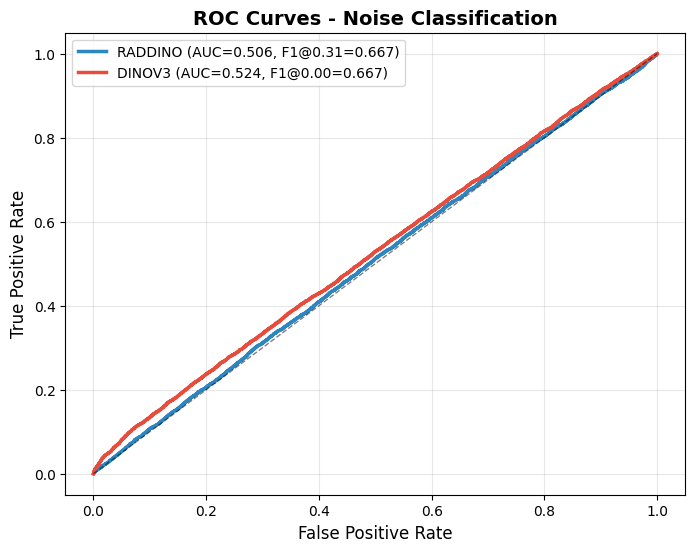


RESULTS SUMMARY TABLE
| Model   | AUC    | F1 Score        |
|:--------|:-------|:----------------|
| RADDINO | 0.5062 | 0.6667 (@0.315) |
| DINOV3  | 0.5243 | 0.6667 (@0.005) |


In [18]:
# Usage
def run_linear_probing():
    # File paths
    BASE_DIR = "/home/rmuthy2/Line-noise/EmbeddingsOutput"
    
    RADDINO_TRAIN = f"{BASE_DIR}/raddino-train-dot4-diagonal.parquet"
    RADDINO_TEST = f"{BASE_DIR}/raddino-test-dot4-diagonal.parquet"
    DINOV3_TRAIN = f"{BASE_DIR}/dinov3-train-dot4-diagonal.parquet"
    DINOV3_TEST = f"{BASE_DIR}/dinov3-test-dot4-diagonal.parquet"
    
    # Run analysis - IMPORTANT: Pass dot_size=4 for dot4 files
    analyzer = LinearProbingAnalyzer()
    results = analyzer.run_analysis(RADDINO_TRAIN, RADDINO_TEST, DINOV3_TRAIN, DINOV3_TEST, dot_size=4)
    
    return analyzer, results

if __name__ == "__main__":
    analyzer, results = run_linear_probing()